# Methods Recap: Pure Gaussian Task

This notebook trains and evaluates all posterior estimation methods in the repository on the `pure_gaussian` task (theta_dim=2, obs_dim=3).

**Methods:**
- **Simulation models**: NPE, FMPE (trained on simulation data)
- **Baselines**: DPE, MF-NPE, RoPE, NPE-PFN
- **Main method**: FM Post Transform (dual flow)

**Evaluation**: Joint metrics (C2ST, MMD, Wasserstein, coverage, LPP) + conditional metrics (cond_C2ST, cond_MMD, true_LPP) using analytical reference posteriors.

## 1. Setup & Imports

In [1]:
%matplotlib inline

import os
import sys
import json
import gc
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm, trange

# Ensure project root is on path
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# npe_pfn lives in a sibling repo
NPE_PFN_PATH = str(PROJECT_ROOT.parent / "npe-pfn")
if NPE_PFN_PATH not in sys.path:
    sys.path.insert(0, NPE_PFN_PATH)

from simulator import get_simulator, generate_simulation_dataset, generate_calibration_dataset
from posteriors import (
    Estimator, DirectPosteriorEstimator, DirectFlowMatchingPosterior,
    DualFlowPosteriorEstimator, RopePosterior, NPEPFNPosterior,
)
from flow_matching.torch_flow import FlowMatching
from training.base import TrainerConfig
from training.trainers.simulation import NPETrainer, FMPETrainer
from training.trainers.baselines import DPETrainer, MFNPETrainer, RoPETrainer, NPEPFNTrainer
from training.trainers.calibration import FMPostTransformTrainer
from utils.metrics import MMD, classifier_two_samples_test, acauc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Project root: {PROJECT_ROOT}")
print(f"npe_pfn path: {NPE_PFN_PATH}")


Fetching list of available datasets from https://causalchamber.s3.eu-central-1.amazonaws.com/downloadables/directory.yaml ... done.
If you use our datasets or simulators for your work please consider citing:

﻿@article{gamella2025chamber,
  author={Gamella, Juan L. and Peters, Jonas and B{"u}hlmann, Peter},
  title={Causal chambers as a real-world physical testbed for {AI} methodology},
  journal={Nature Machine Intelligence},
  doi={10.1038/s42256-024-00964-x},
  year={2025},
}

Device: cpu
Project root: /home/pruhlman/Doctorat/project/ropefm
npe_pfn path: /home/pruhlman/Doctorat/project/npe-pfn


## 2. Task Description

**Pure Gaussian** is a linear-Gaussian task with analytical posteriors:

- **Prior**: $\theta \sim \mathcal{N}(\mu_\theta, \Sigma_\theta)$, with $\theta \in \mathbb{R}^2$
- **Likelihood**: $x | \theta \sim \mathcal{N}(A\theta + b, \Sigma_{\text{lik}})$, with $x \in \mathbb{R}^3$
- **Misspecification layer**: $y | x \sim \mathcal{N}(Cx + d, \Sigma_{\text{noise}})$

This task has:
- Exact analytical posterior $p(\theta | x)$ (well-specified)
- Exact analytical posterior $p(\theta | y)$ (misspecified, marginalizing over $x$)
- `sample_reference_posterior()` for conditional metrics

**Simulation models** (NPE, FMPE) learn $p(\theta|x)$ from simulation data.
When conditioned on $y$ instead of $x$, they are "naive" — exposed to distribution shift.
**Calibration methods** correct for this misspecification using calibration triples $(\theta, x, y)$.

## 3. Configuration

In [2]:
# --- Data sizes ---
N_SIM = 10000
N_CAL = 2000
N_TEST = 1000
NCAL_VALUES = [50, 200, 500, 1000]
SEEDS = [42]

# --- Simulator parameters ---
SIM_PARAMS = {
    "theta_dim": 2,
    "obs_dim": 3,
    "prior_var_scale": 2,
    "likelihood_var_scale": 1,
    "noisy_var_scale": 0.1,
    "seed": 0,
}

# --- Architecture configs (small for low-dim task) ---
NPE_PARAMS = {"npe_params": {"transforms": 3, "hidden_features": [32, 32], "bins": 5}}

FMPE_FLOW_CONFIG = {
    "probability_path": "ot2",
    "prior": "power",
    "base_dist": "gaussian",
    "params": {"drift": {"architecture": "resmlp", "hidden_dim": [32, 32, 32]}},
}

FM_PT_FLOW_CONFIG = {
    "space": "data",
    "conditional": True,
    "probability_path": "ot2",
    "prior": "power",
    "base_dist": "gaussian",
    "params": {"drift": {"architecture": "resmlp", "hidden_dim": [32, 32, 32]}},
}

# --- task_config dict (mirrors YAML structure for trainer classes) ---
task_config = {
    "name": "pure_gaussian",
    "rescale": "z_score",
    "simulator": {"name": "pure_gaussian", "params": SIM_PARAMS},
    "npe": {
        "training": {"lr": 1e-4, "batch_size": 256, "epochs": 1000, "train_size": 0.9,
                     "max_patience": 20, "rescale": "z_score"},
        "params": NPE_PARAMS,
    },
    "dpe": {
        "training": {"lr": 1e-4, "batch_size": 256, "epochs": 2000, "train_size": 0.9,
                     "max_patience": 20, "rescale": "z_score"},
        "params": NPE_PARAMS,
    },
    "fmpe": {
        "training_params": {"rescale": "z_score", "max_patience": 20},
        "config": FMPE_FLOW_CONFIG,
    },
    "fm_post_transform": {
        "training_params": {"rescale": "z_score", "max_patience": None},
        "config": {
            "npe": "fmpe",
            "flow_theta": FM_PT_FLOW_CONFIG,
            "flow_x": FM_PT_FLOW_CONFIG,
        },
    },
    "rope": {"training_params": {"epochs": 2000, "rescale": "z_score"}},
}

# --- Save directory ---
SAVE_DIR = Path("notebooks/recap_checkpoints")

# --- Evaluation params ---
N_JOINT_EVAL = 1000
N_COND_OBS = 5
N_POSTERIOR_SAMPLES = 500

print("Configuration ready.")

Configuration ready.


## 4. Simulator & Data Generation

In [3]:
sim = get_simulator("pure_gaussian", **SIM_PARAMS)
print(f"Simulator: {sim.name}, theta_dim={sim.theta_dim}, obs_dim={sim.obs_dim}")

# Generate datasets
torch.manual_seed(0)
theta_sim, x_sim = generate_simulation_dataset(sim, N_SIM)
theta_cal, x_cal, y_cal = generate_calibration_dataset(sim, N_CAL, generation="independent")
theta_test, x_test, y_test = generate_calibration_dataset(sim, N_TEST, generation="independent")

print(f"Simulation data: theta={theta_sim.shape}, x={x_sim.shape}")
print(f"Calibration data: theta={theta_cal.shape}, x={x_cal.shape}, y={y_cal.shape}")
print(f"Test data: theta={theta_test.shape}, x={x_test.shape}, y={y_test.shape}")

Simulator: pure_gaussian, theta_dim=2, obs_dim=3
Simulation data: theta=torch.Size([10000, 2]), x=torch.Size([10000, 3])
Calibration data: theta=torch.Size([2000, 2]), x=torch.Size([2000, 3]), y=torch.Size([2000, 3])
Test data: theta=torch.Size([1000, 2]), x=torch.Size([1000, 3]), y=torch.Size([1000, 3])


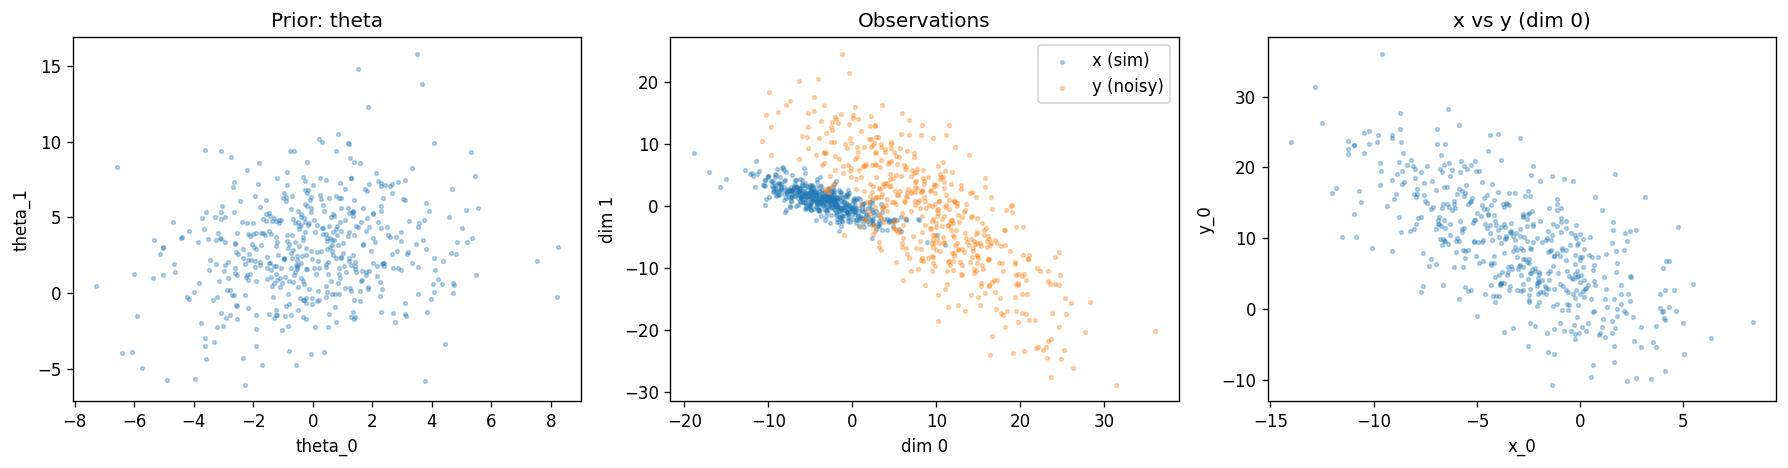

In [4]:
# Quick scatter: theta vs x vs y distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=120)

axes[0].scatter(theta_sim[:500, 0], theta_sim[:500, 1], alpha=0.3, s=5)
axes[0].set_title("Prior: theta")
axes[0].set_xlabel("theta_0"); axes[0].set_ylabel("theta_1")

axes[1].scatter(x_sim[:500, 0], x_sim[:500, 1], alpha=0.3, s=5, label="x (sim)")
axes[1].scatter(y_cal[:500, 0], y_cal[:500, 1], alpha=0.3, s=5, label="y (noisy)")
axes[1].set_title("Observations")
axes[1].set_xlabel("dim 0"); axes[1].set_ylabel("dim 1")
axes[1].legend()

axes[2].scatter(x_cal[:500, 0], y_cal[:500, 0], alpha=0.3, s=5)
axes[2].set_title("x vs y (dim 0)")
axes[2].set_xlabel("x_0"); axes[2].set_ylabel("y_0")

plt.tight_layout()
plt.show()

## 5. Save/Load Utilities

In [5]:
def save_model(model, name, subdir=""):
    """Save Estimator or FlowMatching using their native .save() API."""
    path = SAVE_DIR / subdir / name
    path.mkdir(parents=True, exist_ok=True)
    if hasattr(model, 'save'):
        model.save(path)
    else:
        torch.save(model.state_dict(), path / "weights.pth")

def load_model(cls, name, subdir="", device="cpu"):
    """Load using native .load() classmethod."""
    path = SAVE_DIR / subdir / name
    return cls.load(path, device=torch.device(device))

def save_posterior(posterior, name, subdir=""):
    """Save a full posterior (pickle for complex wrappers like DualFlow)."""
    path = SAVE_DIR / subdir
    path.mkdir(parents=True, exist_ok=True)
    torch.save(posterior, path / f"{name}.pt")

def load_posterior(name, subdir="", device="cpu"):
    return torch.load(SAVE_DIR / subdir / f"{name}.pt", map_location=device, weights_only=False)

def save_samples(samples, name, subdir=""):
    path = SAVE_DIR / subdir
    path.mkdir(parents=True, exist_ok=True)
    torch.save(samples, path / f"{name}_samples.pt")

def load_samples(name, subdir=""):
    return torch.load(SAVE_DIR / subdir / f"{name}_samples.pt")

def model_exists(name, subdir=""):
    return (SAVE_DIR / subdir / name).exists() or (SAVE_DIR / subdir / f"{name}.pt").exists()

print(f"Save directory: {SAVE_DIR}")

Save directory: notebooks/recap_checkpoints


## 6. Phase 1: Train Simulation Models

NPE and FMPE are trained once on `(theta_sim, x_sim)` and shared across all calibration sizes.

In [6]:
# --- Train NPE ---
print("=" * 60)
print("Training NPE on simulation data")
print("=" * 60)

npe_config = TrainerConfig(
    epochs=1000, lr=1e-4, batch_size=256, train_size=0.9,
    max_patience=20, rescale="z_score", save=False, load=False,
)
npe_trainer = NPETrainer(npe_config, model_path=SAVE_DIR / "npe", task_config=task_config)
npe_posterior = npe_trainer.train((theta_sim, x_sim), device)
npe_posterior.cpu()

save_model(npe_posterior.posterior, "npe", subdir="simulation")
print(f"NPE trained. Best val loss: {npe_trainer.state.best_val_loss:.4f}")

Training NPE on simulation data
Using z_score rescaling.
  Rescaling: z_score
  Epochs: 1000, LR: 0.0001, Batch size: 256
  Early stopping: max_patience=20


Training NPE:   0%|          | 0/1000 [00:00<?, ?it/s]

	Early stopping at epoch 148
	Best validation loss: 0.3827
NPE trained. Best val loss: 0.3827


In [7]:
# --- Train FMPE ---
print("=" * 60)
print("Training FMPE on simulation data")
print("=" * 60)

fmpe_config = TrainerConfig(
    epochs=500, lr=1e-3, batch_size=256, train_size=0.9,
    max_patience=20, rescale="z_score", save=False, load=False,
)
fmpe_trainer = FMPETrainer(fmpe_config, model_path=SAVE_DIR / "fmpe", task_config=task_config)
fmpe_posterior = fmpe_trainer.train((theta_sim, x_sim), device)
fmpe_posterior.cpu()

save_model(fmpe_posterior.flow, "fmpe", subdir="simulation")
print(f"FMPE trained. Best val loss: {fmpe_trainer.state.best_val_loss:.4f}")

Training FMPE on simulation data
  Rescaling: z_score
  Epochs: 500, LR: 0.001, Batch size: 256
  Early stopping: max_patience=20


Training FMPE:   0%|          | 0/500 [00:00<?, ?it/s]

	Early stopping at epoch 49
	Best validation loss: 0.5667
FMPE trained. Best val loss: 0.5667


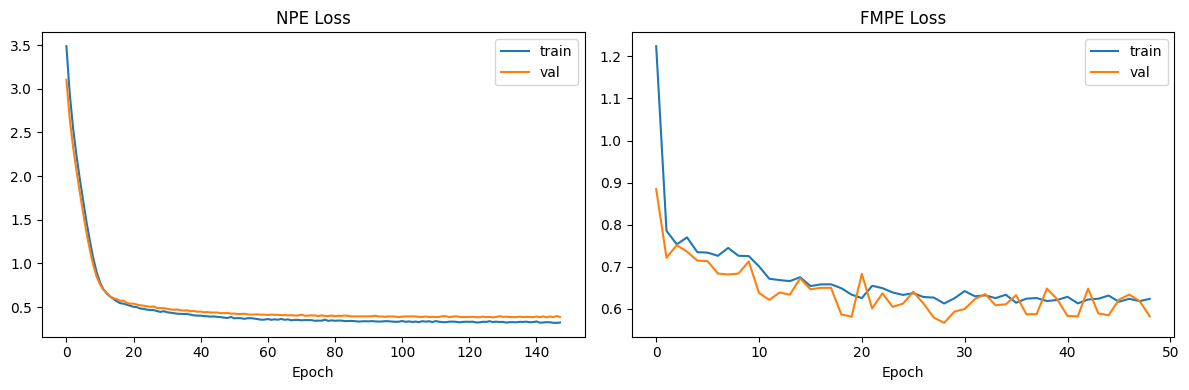

In [9]:
# --- Loss curves ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

npe_loss = npe_trainer.state.loss_history
axes[0].plot(npe_loss["train"], label="train")
axes[0].plot(npe_loss["val"], label="val")
axes[0].set_title("NPE Loss")
axes[0].set_xlabel("Epoch"); axes[0].legend()

fmpe_loss = fmpe_trainer.state.loss_history
axes[1].plot(fmpe_loss["train"], label="train")
axes[1].plot(fmpe_loss["val"], label="val")
axes[1].set_title("FMPE Loss")
axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.show()

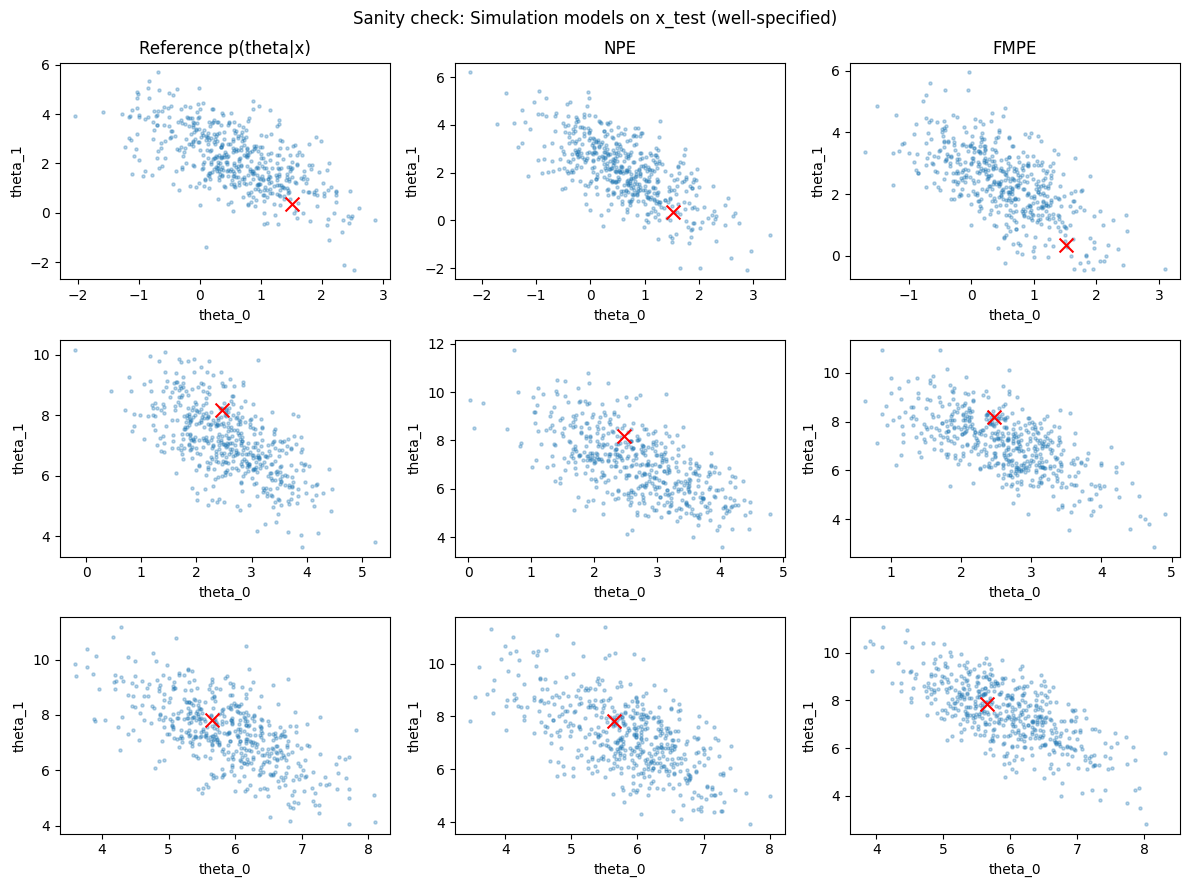

In [10]:
# --- Sanity check: sample from NPE/FMPE on test x ---
n_check = 3
n_samples_check = 500

with torch.no_grad():
    npe_samples = npe_posterior.sample(x_test[:n_check].to(device), n_samples_check, device).cpu()
    fmpe_samples = fmpe_posterior.sample(x_test[:n_check].to(device), n_samples_check, device).cpu()

# Reference posterior p(theta|x) (well-specified)
ref_samples_x = sim.sample_reference_posterior(n_samples_check, x_test[:n_check], misspecified=True)

fig, axes = plt.subplots(n_check, 3, figsize=(12, 3 * n_check))
for i in range(n_check):
    for j, (samples, label) in enumerate([
        (ref_samples_x[:, i], "Reference p(theta|x)"),
        (npe_samples[:, i], "NPE"),
        (fmpe_samples[:, i], "FMPE"),
    ]):
        axes[i, j].scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=5)
        axes[i, j].scatter(theta_test[i, 0], theta_test[i, 1], c="red", marker="x", s=100, zorder=5)
        if i == 0:
            axes[i, j].set_title(label)
        axes[i, j].set_xlabel("theta_0"); axes[i, j].set_ylabel("theta_1")

plt.suptitle("Sanity check: Simulation models on x_test (well-specified)")
plt.tight_layout()
plt.show()

## 7. Phase 2: Train Baselines & Main Method

For each calibration size, train DPE, MF-NPE, RoPE, NPE-PFN, and FM Post Transform.

In [11]:
# Store loss histories (small) and track which methods were trained per ncal
all_loss_histories = {}
trained_methods_per_ncal = {}  # {ncal: [method_names]}

for ncal in NCAL_VALUES:
    print(f"\n{'=' * 60}")
    print(f"NCAL = {ncal}")
    print(f"{'=' * 60}")

    trained = []

    # Subsample calibration data
    th_cal = theta_cal[:ncal]
    x_c = x_cal[:ncal]
    y_c = y_cal[:ncal]
    cal_data = (th_cal, x_c, y_c)

    # ---- a) DPE ----
    print(f"\n--- DPE (ncal={ncal}) ---")
    dpe_cfg = TrainerConfig(
        epochs=2000, lr=1e-4, batch_size=min(ncal // 4, 64), train_size=0.9,
        max_patience=20, rescale="z_score", save=False, load=False,
    )
    dpe_trainer = DPETrainer(dpe_cfg, model_path=SAVE_DIR / f"dpe_ncal{ncal}", task_config=task_config)
    dpe_post = dpe_trainer.train(cal_data, device)
    dpe_post.cpu()
    save_posterior(dpe_post, f"dpe_ncal{ncal}", subdir="posteriors")
    all_loss_histories.setdefault("dpe", {})[ncal] = dpe_trainer.state.loss_history
    best_dpe = min(dpe_trainer.state.loss_history["val"]) if dpe_trainer.state.loss_history["val"] else float('nan')
    print(f"  DPE done. Best val: {best_dpe:.4f}")
    trained.append("dpe")
    del dpe_post, dpe_trainer; gc.collect()

    # ---- b) MF-NPE ----
    print(f"\n--- MF-NPE (ncal={ncal}) ---")
    mfnpe_cfg = TrainerConfig(
        epochs=500, lr=1e-5, batch_size=min(ncal // 4, 64), train_size=0.9,
        max_patience=20, rescale="z_score", save=False, load=False,
    )
    mfnpe_trainer = MFNPETrainer(mfnpe_cfg, model_path=SAVE_DIR / f"mfnpe_ncal{ncal}", task_config=task_config)
    mfnpe_post = mfnpe_trainer.train(cal_data, device, npe=npe_posterior)
    mfnpe_post.cpu()
    save_posterior(mfnpe_post, f"mf_npe_ncal{ncal}", subdir="posteriors")
    all_loss_histories.setdefault("mf_npe", {})[ncal] = mfnpe_trainer.state.loss_history
    best_mfnpe = min(mfnpe_trainer.state.loss_history["val"]) if mfnpe_trainer.state.loss_history["val"] else float('nan')
    print(f"  MF-NPE done. Best val: {best_mfnpe:.4f}")
    trained.append("mf_npe")
    del mfnpe_post, mfnpe_trainer; gc.collect()

    # ---- c) RoPE ----
    # Note: pure_gaussian uses nn.Identity embedding, so RoPE degenerates to NPE.
    print(f"\n--- RoPE (ncal={ncal}) ---")
    rope_cfg = TrainerConfig(
        epochs=2000, lr=1e-4, batch_size=min(ncal // 4, 64), train_size=0.9,
        max_patience=20, rescale="z_score", save=False, load=False,
    )
    rope_trainer = RoPETrainer(rope_cfg, model_path=SAVE_DIR / f"rope_ncal{ncal}", task_config=task_config)
    rope_post = rope_trainer.train(cal_data, device, npe=npe_posterior)
    rope_post.cpu()
    # Set simulation data for OT-based sampling
    rope_post.set_sim_data(x_sim[:N_TEST], theta_sim[:N_TEST])
    save_posterior(rope_post, f"rope_ncal{ncal}", subdir="posteriors")
    print(f"  RoPE done.")
    trained.append("rope")
    del rope_post, rope_trainer; gc.collect()

    # ---- d) NPE-PFN ----
    print(f"\n--- NPE-PFN (ncal={ncal}) ---")
    try:
        pfn_cfg = TrainerConfig(save=False, load=False)
        pfn_trainer = NPEPFNTrainer(pfn_cfg, model_path=SAVE_DIR / f"pfn_ncal{ncal}", task_config=task_config)
        pfn_post = pfn_trainer.train(cal_data, device)
        save_posterior(pfn_post, f"npe_pfn_ncal{ncal}", subdir="posteriors")
        print(f"  NPE-PFN done.")
        trained.append("npe_pfn")
        del pfn_post, pfn_trainer; gc.collect()
    except Exception as e:
        print(f"  NPE-PFN skipped: {e}")

    # ---- e) FM Post Transform ----
    print(f"\n--- FM Post Transform (ncal={ncal}) ---")
    model_path = SAVE_DIR / f"fm_pt_ncal{ncal}"
    model_path.mkdir(parents=True, exist_ok=True)

    # Save FMPE weights+config for FMPostTransformTrainer._load_npe()
    torch.save(fmpe_posterior.flow.state_dict(), model_path / "npe_fmpe.pth")
    with open(model_path / "npe_fmpe.json", "w") as f:
        json.dump(FMPE_FLOW_CONFIG, f)
    # Save simulator config for _load_simulator()
    with open(model_path / "simulator.json", "w") as f:
        json.dump({"name": "pure_gaussian", "params": SIM_PARAMS}, f)

    fmpt_cfg = TrainerConfig(
        epochs=200, lr=1e-3, batch_size=min(ncal // 4, 64), train_size=0.9,
        max_patience=30, rescale="z_score", save=False, load=False,
    )
    fmpt_trainer = FMPostTransformTrainer(fmpt_cfg, model_path=model_path, task_config=task_config)
    fmpt_post = fmpt_trainer.train(cal_data, device)
    fmpt_post.cpu()
    save_posterior(fmpt_post, f"fm_post_transform_ncal{ncal}", subdir="posteriors")
    all_loss_histories.setdefault("fm_post_transform", {})[ncal] = fmpt_trainer.state.loss_history
    print(f"  FM Post Transform done.")
    trained.append("fm_post_transform")
    del fmpt_post, fmpt_trainer; gc.collect()

    trained_methods_per_ncal[ncal] = trained

    # Aggressive cleanup between ncal iterations
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Save the simulation posteriors for evaluation, then free them
save_posterior(npe_posterior, "npe_naive", subdir="posteriors")
save_posterior(fmpe_posterior, "fmpe_naive", subdir="posteriors")
del npe_posterior, fmpe_posterior, npe_trainer, fmpe_trainer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\nAll methods trained for ncal values: {NCAL_VALUES}")
print(f"Trained methods per ncal: {trained_methods_per_ncal}")


NCAL = 50

--- DPE (ncal=50) ---
Using z_score rescaling.
  Rescaling: z_score
  Epochs: 2000, LR: 0.0001, Batch size: 12
  Early stopping: max_patience=20


Training DPE:   0%|          | 0/2000 [00:00<?, ?it/s]

	Early stopping at epoch 138
  DPE done. Best val: 0.9314

--- MF-NPE (ncal=50) ---
	Loading pretrained NPE from provided model
Using z_score rescaling.
  Rescaling: z_score
  Epochs: 500, LR: 1e-05, Batch size: 12
  Early stopping: max_patience=20


Training MF-NPE:   0%|          | 0/500 [00:00<?, ?it/s]

  MF-NPE done. Best val: 2.0041

--- RoPE (ncal=50) ---
Using z_score rescaling.
	Embedding network is Identity - no fine-tuning required
  RoPE done.

--- NPE-PFN (ncal=50) ---
  NPE-PFN: Storing 50 calibration samples as context
  Filter type: latest_filtering, Context size limit: 10000
  NPE-PFN done.

--- FM Post Transform (ncal=50) ---
  Rescaling: z_score
  Epochs: 200, LR: 0.001, Batch size: 12
  Early stopping: max_patience=30


...

	Early stopping at epoch 154
  DPE done. Best val: 0.5614

--- MF-NPE (ncal=1000) ---
	Loading pretrained NPE from provided model
Using z_score rescaling.
  Rescaling: z_score
  Epochs: 500, LR: 1e-05, Batch size: 64
  Early stopping: max_patience=20


Training MF-NPE:   0%|          | 0/500 [00:00<?, ?it/s]

  MF-NPE done. Best val: 0.7512

--- RoPE (ncal=1000) ---
Using z_score rescaling.
	Embedding network is Identity - no fine-tuning required
  RoPE done.

--- NPE-PFN (ncal=1000) ---
  NPE-PFN: Storing 1000 calibration samples as context
  Filter type: latest_filtering, Context size limit: 10000
  NPE-PFN done.

--- FM Post Transform (ncal=1000) ---
  Rescaling: z_score
  Epochs: 200, LR: 0.001, Batch size: 64
  Early stopping: max_patience=30


Training FM Post Transform:   0%|          | 0/200 [00:00<?, ?it/s]

	Early stopping at epoch 74
  FM Post Transform done.

All methods trained for ncal values: [50, 200, 500, 1000]
Trained methods per ncal: {50: ['dpe', 'mf_npe', 'rope', 'npe_pfn', 'fm_post_transform'], 200: ['dpe', 'mf_npe', 'rope', 'npe_pfn', 'fm_post_transform'], 500: ['dpe', 'mf_npe', 'rope', 'npe_pfn', 'fm_post_transform'], 1000: ['dpe', 'mf_npe', 'rope', 'npe_pfn', 'fm_post_transform']}


## 8. Phase 3: Evaluation

Compute joint and conditional metrics for all methods.

In [12]:
# --- Metric computation functions ---

from scipy.stats import wasserstein_distance
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score


def compute_joint_c2st(theta_true, theta_samples, y_obs):
    """C2ST on joint (theta, y). Perfect = 0.5."""
    joint_true = torch.cat([theta_true, y_obs.reshape(len(theta_true), -1)], dim=1)
    joint_post = torch.cat([theta_samples, y_obs.reshape(len(theta_samples), -1)], dim=1)
    n = len(theta_true)
    X = torch.cat([joint_true, joint_post], dim=0).numpy()
    y = np.concatenate([np.zeros(n), np.ones(n)])
    clf = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=500, random_state=42)
    scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
    return float(scores.mean())


def compute_joint_mmd(theta_true, theta_samples, y_obs):
    """MMD on joint (theta, y). Lower = better."""
    joint_true = torch.cat([theta_true, y_obs.reshape(len(theta_true), -1)], dim=1)
    joint_post = torch.cat([theta_samples, y_obs.reshape(len(theta_samples), -1)], dim=1)
    return float(MMD(joint_true, joint_post, kernel="multiscale"))


def compute_joint_wasserstein(theta_true, theta_samples, y_obs):
    """1D Wasserstein per dimension, averaged."""
    joint_true = torch.cat([theta_true, y_obs.reshape(len(theta_true), -1)], dim=1).numpy()
    joint_post = torch.cat([theta_samples, y_obs.reshape(len(theta_samples), -1)], dim=1).numpy()
    distances = [wasserstein_distance(joint_true[:, d], joint_post[:, d]) for d in range(joint_true.shape[1])]
    return float(np.mean(distances))


def compute_coverage(theta_true, theta_samples):
    """ACAUC. 0 = perfect calibration."""
    # theta_samples: (n_obs, n_samples, theta_dim) -> (n_samples, n_obs, theta_dim)
    return float(acauc(theta_true, theta_samples.transpose(0, 1)))


def compute_lpp(model, theta_true, y_obs, dev, batch_size=100):
    """Mean log posterior probability."""
    if not hasattr(model, 'log_prob'):
        return float('nan')
    lpp_values = []
    n = len(y_obs)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        lp = model.log_prob(theta_true[start:end].to(dev), y_obs[start:end].to(dev))
        lpp_values.append(lp.detach().cpu())
    return float(torch.cat(lpp_values).mean())


def compute_conditional_c2st(model_samples, reference_samples):
    """C2ST per observation, averaged. model_samples/reference: (n_obs, n_samples, theta_dim)."""
    n_obs = model_samples.shape[0]
    c2st_vals = []
    for i in range(n_obs):
        ms = model_samples[i]
        rs = reference_samples[i]
        n = min(len(ms), len(rs))
        X = torch.cat([ms[:n], rs[:n]], dim=0).numpy()
        y = np.concatenate([np.zeros(n), np.ones(n)])
        clf = MLPClassifier(hidden_layer_sizes=(32, 32), max_iter=300, random_state=42)
        try:
            scores = cross_val_score(clf, X, y, cv=3, scoring="accuracy")
            c2st_vals.append(scores.mean())
        except Exception:
            pass
    return float(np.mean(c2st_vals)) if c2st_vals else float('nan')


def compute_conditional_mmd(model_samples, reference_samples):
    """MMD per observation, averaged."""
    n_obs = model_samples.shape[0]
    mmd_vals = []
    for i in range(n_obs):
        ms = model_samples[i]
        rs = reference_samples[i]
        mmd_vals.append(float(MMD(ms, rs, kernel="multiscale")))
    return float(np.mean(mmd_vals))


def compute_true_lpp(theta_samples, y_obs, simulator):
    """True posterior log-prob on method-generated samples. theta_samples: (n_obs, n_samples, theta_dim)."""
    n_obs = theta_samples.shape[0]
    lpp_vals = []
    for i in range(n_obs):
        true_post = simulator.post_dist(y_obs[i:i+1], misspecified=False)
        lp = true_post.log_prob(theta_samples[i])
        lpp_vals.append(lp.mean().item())
    return float(np.mean(lpp_vals))


def sample_from_model(model, y_obs, n_samples, dev, is_rope=False, x_sim_data=None, theta_sim_data=None):
    """Sample from a posterior model, handling shapes correctly."""
    if is_rope and hasattr(model, 'set_sim_data') and x_sim_data is not None:
        model.set_sim_data(x_sim_data, theta_sim_data)
    with torch.no_grad():
        samples = model.sample(y_obs.to(dev), n_samples, dev).cpu()
    # samples shape: (n_samples, n_obs, theta_dim)
    return samples


print("Metric functions defined.")

Metric functions defined.


In [ ]:
# --- Evaluate all methods ---
# Load posteriors from disk one at a time to avoid OOM

results = []

# Fixed methods (simulation models applied naively to y)
fixed_method_names = ["npe_naive", "fmpe_naive"]

# NPE-PFN requires batched evaluation to avoid OOM
PFN_BATCH_SIZE = 50  # Process this many observations at a time for NPE-PFN


def sample_batched(model, y_obs, n_samples, dev, batch_size, is_rope=False):
    """Sample in batches to avoid OOM for memory-heavy models like NPE-PFN."""
    all_samples = []
    for start in range(0, len(y_obs), batch_size):
        end = min(start + batch_size, len(y_obs))
        batch = sample_from_model(model, y_obs[start:end], n_samples, dev, is_rope, x_sim[:N_TEST], theta_sim[:N_TEST])
        all_samples.append(batch)
    return torch.cat(all_samples, dim=1)  # concat along obs dim


for ncal in NCAL_VALUES:
    print(f"\n{'=' * 60}")
    print(f"Evaluating ncal={ncal}")
    print(f"{'=' * 60}")

    # Build list of method names to evaluate
    method_names = list(fixed_method_names) + trained_methods_per_ncal.get(ncal, [])

    # Test data for joint metrics
    n_joint = min(N_JOINT_EVAL, len(y_test))
    th_true_j = theta_test[:n_joint]
    y_obs_j = y_test[:n_joint]

    # Test data for conditional metrics
    n_cond = min(N_COND_OBS, len(y_test))
    y_obs_c = y_test[:n_cond]

    # Reference posterior samples for conditional metrics: p(theta|y)
    ref_samples_list = []
    for i in range(n_cond):
        rs = sim.sample_reference_posterior(N_POSTERIOR_SAMPLES, y_obs_c[i:i+1], misspecified=False)
        if rs.ndim == 3:
            rs = rs[:, 0, :]  # (n_samples, theta_dim)
        ref_samples_list.append(rs)
    ref_samples = torch.stack(ref_samples_list, dim=0)  # (n_cond, n_samples, theta_dim)

    for method_name in method_names:
        print(f"\n  --- {method_name} ---")
        row = {"method": method_name, "ncal": ncal}

        # Load posterior from disk
        if method_name in fixed_method_names:
            posterior_key = method_name
        else:
            posterior_key = f"{method_name}_ncal{ncal}"

        try:
            model = load_posterior(posterior_key, subdir="posteriors", device="cpu")
            is_rope = method_name == "rope"
            is_pfn = method_name == "npe_pfn"
            model.to(device)

            # --- Joint metrics: 1 sample per observation ---
            if is_pfn:
                joint_samples = sample_batched(model, y_obs_j, 1, device, PFN_BATCH_SIZE)
            else:
                joint_samples = sample_from_model(model, y_obs_j, 1, device, is_rope, x_sim[:N_TEST], theta_sim[:N_TEST])
            joint_samples = joint_samples.squeeze(0)  # (n_joint, theta_dim)
            if joint_samples.dim() == 1:
                joint_samples = joint_samples.unsqueeze(-1)

            row["joint_c2st"] = compute_joint_c2st(th_true_j, joint_samples, y_obs_j)
            row["joint_mmd"] = compute_joint_mmd(th_true_j, joint_samples, y_obs_j)
            row["joint_wasserstein"] = compute_joint_wasserstein(th_true_j, joint_samples, y_obs_j)
            del joint_samples; gc.collect()

            # Coverage: many samples per obs (reduce for PFN to avoid OOM)
            n_cov = 20 if is_pfn else 100
            if is_pfn:
                cov_samples = sample_batched(model, y_obs_j, n_cov, device, PFN_BATCH_SIZE)
            else:
                cov_samples = sample_from_model(model, y_obs_j, n_cov, device, is_rope, x_sim[:N_TEST], theta_sim[:N_TEST])
            cov_samples = cov_samples.permute(1, 0, 2)  # (n_joint, n_cov, theta_dim)
            row["joint_coverage"] = compute_coverage(th_true_j, cov_samples)
            del cov_samples; gc.collect()

            # LPP
            try:
                row["lpp"] = compute_lpp(model, th_true_j, y_obs_j, device, batch_size=50 if is_pfn else 100)
            except Exception as e:
                row["lpp"] = float('nan')
                print(f"    LPP failed: {e}")

            # --- Conditional metrics: many samples per observation ---
            cond_samples = sample_from_model(model, y_obs_c, N_POSTERIOR_SAMPLES, device, is_rope, x_sim[:N_TEST], theta_sim[:N_TEST])
            # cond_samples: (n_samples, n_cond, theta_dim) -> (n_cond, n_samples, theta_dim)
            cond_samples = cond_samples.permute(1, 0, 2)

            row["cond_c2st"] = compute_conditional_c2st(cond_samples, ref_samples)
            row["cond_mmd"] = compute_conditional_mmd(cond_samples, ref_samples)
            row["true_lpp"] = compute_true_lpp(cond_samples, y_obs_c, sim)

            # Save samples for pair plots
            save_samples(cond_samples, f"{method_name}_ncal{ncal}", subdir="eval_samples")

            # Free memory immediately
            del cond_samples
            model.cpu()
            del model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            print(f"    ERROR: {e}")
            import traceback
            traceback.print_exc()
            for m in ["joint_c2st", "joint_mmd", "joint_wasserstein", "joint_coverage",
                      "lpp", "cond_c2st", "cond_mmd", "true_lpp"]:
                row.setdefault(m, float('nan'))

        results.append(row)
        print(f"    Results: { {k: f'{v:.4f}' if isinstance(v, float) else v for k, v in row.items()} }")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_results = pd.DataFrame(results)
print(f"\nEvaluation complete. {len(df_results)} rows.")
df_results


Evaluating ncal=50

  --- npe_naive ---
    Results: {'method': 'npe_naive', 'ncal': 50, 'joint_c2st': '0.9945', 'joint_mmd': '0.0470', 'joint_wasserstein': '2.2051', 'joint_coverage': '0.4428', 'lpp': '-20.8205', 'cond_c2st': '1.0000', 'cond_mmd': '2.8484', 'true_lpp': '-255.0807'}

  --- fmpe_naive ---
    Results: {'method': 'fmpe_naive', 'ncal': 50, 'joint_c2st': '0.9970', 'joint_mmd': '0.0448', 'joint_wasserstein': '2.9071', 'joint_coverage': '0.4270', 'lpp': '-49.8031', 'cond_c2st': '1.0000', 'cond_mmd': '1.8127', 'true_lpp': '-300.0381'}

  --- dpe ---


/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged ye

    Results: {'method': 'dpe', 'ncal': 50, 'joint_c2st': '0.6380', 'joint_mmd': '0.0070', 'joint_wasserstein': '0.0733', 'joint_coverage': '-0.0139', 'lpp': '-0.9153', 'cond_c2st': '0.6886', 'cond_mmd': '0.2155', 'true_lpp': '-5.0801'}

  --- mf_npe ---


/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged ye

    Results: {'method': 'mf_npe', 'ncal': 50, 'joint_c2st': '0.8195', 'joint_mmd': '0.0101', 'joint_wasserstein': '0.2003', 'joint_coverage': '-0.0874', 'lpp': '-1.8523', 'cond_c2st': '0.8460', 'cond_mmd': '0.5534', 'true_lpp': '-20.2706'}

  --- rope ---


...

/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


    Results: {'method': 'mf_npe', 'ncal': 500, 'joint_c2st': '0.6490', 'joint_mmd': '0.0073', 'joint_wasserstein': '0.1110', 'joint_coverage': '-0.0312', 'lpp': '-0.8615', 'cond_c2st': '0.6230', 'cond_mmd': '0.1481', 'true_lpp': '-3.6374'}

  --- rope ---


/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged ye

    Results: {'method': 'rope', 'ncal': 500, 'joint_c2st': '0.8970', 'joint_mmd': '0.0154', 'joint_wasserstein': '0.0599', 'joint_coverage': '0.0917', 'lpp': '-2.9751', 'cond_c2st': '0.9404', 'cond_mmd': '0.8940', 'true_lpp': '-55.9667'}

  --- npe_pfn ---


/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/tabpfn/validation.py:56: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/tabpfn/validation.py:56: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/tabpfn/validation.py:56: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
/home/pruhlman/miniconda3/envs/fmcpe/lib/python3.12/site-packages/tabpfn/validation.py:56: UserWarning: Running on CPU with more than 200 samples may be s

## 9. Results Display

In [ ]:
# --- Metrics tables: pivot per metric ---
metrics_list = ["joint_c2st", "joint_mmd", "joint_wasserstein", "joint_coverage",
                "lpp", "cond_c2st", "cond_mmd", "true_lpp"]

for metric in metrics_list:
    if metric in df_results.columns:
        pivot = df_results.pivot(index="method", columns="ncal", values=metric)
        print(f"\n{'=' * 40}")
        print(f"  {metric}")
        print(f"{'=' * 40}")
        display(pivot.round(4))

In [ ]:
# --- Line plots: metrics vs ncal ---
method_colors = {
    "fm_post_transform": "tab:blue",
    "dpe": "tab:orange",
    "mf_npe": "tab:green",
    "rope": "tab:brown",
    "npe_pfn": "tab:cyan",
    "npe_naive": "tab:olive",
    "fmpe_naive": "tab:red",
}

# Ideal reference values
ideal_refs = {
    "joint_c2st": 0.5,
    "cond_c2st": 0.5,
    "joint_coverage": 0.0,
}

plot_metrics = [m for m in metrics_list if m in df_results.columns]
n_plots = len(plot_metrics)
ncols = min(4, n_plots)
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
if nrows == 1 and ncols == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes)

for idx, metric in enumerate(plot_metrics):
    ax = axes[idx // ncols, idx % ncols]
    for method_name in df_results["method"].unique():
        method_df = df_results[df_results["method"] == method_name].sort_values("ncal")
        color = method_colors.get(method_name, "gray")
        ax.plot(method_df["ncal"], method_df[metric], "o-", label=method_name, color=color)

    if metric in ideal_refs:
        ax.axhline(ideal_refs[metric], color="black", linestyle="--", alpha=0.5, label="ideal")

    ax.set_title(metric)
    ax.set_xlabel("ncal")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_plots, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.suptitle("Metrics vs Calibration Size", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Pair Plots

Compare posterior samples from each method against reference posterior for selected test observations.

In [ ]:
n_plot_obs = 3  # Number of test observations to plot
n_plot_samples = 500

# Methods to include in pair plots
plot_method_names = ["npe_naive", "fmpe_naive", "dpe", "mf_npe", "rope", "npe_pfn", "fm_post_transform"]

for ncal in NCAL_VALUES:
    print(f"\nPair plots for ncal={ncal}")

    # Figure out which methods are available for this ncal
    available_methods = []
    for m in plot_method_names:
        if m in fixed_method_names:
            available_methods.append(m)
        elif m in trained_methods_per_ncal.get(ncal, []):
            available_methods.append(m)

    n_methods = len(available_methods)
    fig, axes = plt.subplots(n_plot_obs, n_methods, figsize=(3.5 * n_methods, 3.5 * n_plot_obs))
    if n_plot_obs == 1:
        axes = axes[np.newaxis, :]

    y_obs_plot = y_test[:n_plot_obs]

    # Reference samples: p(theta|y)
    ref_plot = []
    for i in range(n_plot_obs):
        rs = sim.sample_reference_posterior(n_plot_samples, y_obs_plot[i:i+1], misspecified=False)
        if rs.ndim == 3:
            rs = rs[:, 0, :]
        ref_plot.append(rs)

    for j, method_name in enumerate(available_methods):
        # Load posterior from disk
        if method_name in fixed_method_names:
            posterior_key = method_name
        else:
            posterior_key = f"{method_name}_ncal{ncal}"

        model = load_posterior(posterior_key, subdir="posteriors", device="cpu")
        model.to(device)
        is_rope = method_name == "rope"

        with torch.no_grad():
            if is_rope and hasattr(model, 'set_sim_data'):
                model.set_sim_data(x_sim[:N_TEST], theta_sim[:N_TEST])

            for i in range(n_plot_obs):
                ax = axes[i, j]

                # Method samples
                samples = model.sample(y_obs_plot[i:i+1].to(device), n_plot_samples, device).cpu()
                if samples.ndim == 3:
                    if samples.shape[0] == n_plot_samples:
                        samples = samples[:, 0, :]
                    else:
                        samples = samples[0]

                # Reference samples (gray background)
                ax.scatter(ref_plot[i][:, 0], ref_plot[i][:, 1], alpha=0.15, s=5, c="gray", label="ref" if i == 0 else None)
                # Method samples (colored)
                color = method_colors.get(method_name, "tab:purple")
                ax.scatter(samples[:, 0], samples[:, 1], alpha=0.25, s=5, c=color, label=method_name if i == 0 else None)
                # True theta
                ax.scatter(theta_test[i, 0], theta_test[i, 1], c="red", marker="x", s=80, zorder=5)

                if i == 0:
                    ax.set_title(method_name, fontsize=10)
                if j == 0:
                    ax.set_ylabel(f"obs {i}", fontsize=10)
                ax.set_xlabel("$\\theta_0$", fontsize=8)
                ax.set_ylabel("$\\theta_1$", fontsize=8)

        # Free memory
        model.cpu()
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    plt.suptitle(f"Posterior samples vs reference p(theta|y) — ncal={ncal}", fontsize=13)
    plt.tight_layout()
    plt.show()

print("\nDone.")